In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Загрузка данных

In [2]:
df = pd.read_csv('Data.csv')
print(f"Размер датасета: {df.shape}")
df.head(2)

Размер датасета: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No


# Обработка пропусков

In [3]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print(f'Пропусков в TotalCharges: {df["TotalCharges"].isnull().sum()}')

Пропусков в TotalCharges: 11


In [4]:
df = df.dropna()
print(f"Размер после удаления пропусков: {df.shape}")

Размер после удаления пропусков: (7032, 21)


# Кодирование категориальных признаков

In [5]:
from sklearn.preprocessing import LabelEncoder

categorical_cols = df.select_dtypes(include='object').columns.tolist()
categorical_cols.remove('customerID')

le = LabelEncoder()
for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

# Распределение целевой переменной

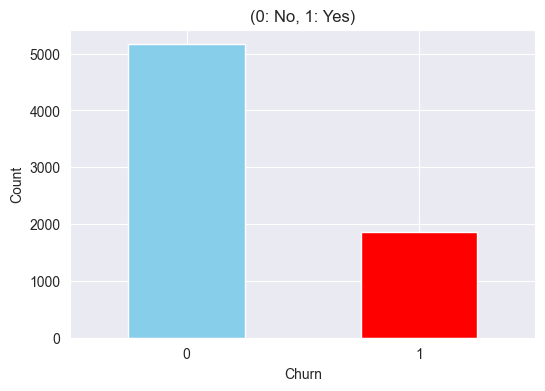

In [6]:
plt.figure(figsize=(6, 4))
df['Churn'].value_counts().plot(kind='bar', color=['skyblue', 'red'])
plt.title('(0: No, 1: Yes)')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

# Подготовка признаков и целевой переменной

In [7]:
from sklearn.model_selection import train_test_split

X = df.drop(['Churn', 'customerID'], axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Обучение модели RF

In [9]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

# Метрики RF

In [11]:
from sklearn.metrics import roc_auc_score, accuracy_score, precision_score, recall_score, f1_score

print(f'Accuracy: {accuracy_score(y_test, y_pred):.3f}')
print(f'Precision: {precision_score(y_test, y_pred):.3f}')
print(f'Recall: {recall_score(y_test, y_pred):.3f}')
print(f'F1-Score: {f1_score(y_test, y_pred):.3f}')

Accuracy: 0.780
Precision: 0.610
Recall: 0.476
F1-Score: 0.535


# Обучение XGBoost

In [15]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(random_state=42, eval_metric='logloss')
xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)
y_pred_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]

acc_xgb = accuracy_score(y_test, y_pred_xgb)
prec_xgb = precision_score(y_test, y_pred_xgb)
rec_xgb = recall_score(y_test, y_pred_xgb)
f1_xgb = f1_score(y_test, y_pred_xgb)
auc_xgb = roc_auc_score(y_test, y_pred_proba_xgb)

print(f'XGBoost - Accuracy: {acc_xgb:.3f}, Precision: {prec_xgb:.3f}, Recall: {rec_xgb:.3f}, F1: {f1_xgb:.3f}, AUC: {auc_xgb:.3f}')

XGBoost - Accuracy: 0.765, Precision: 0.564, Recall: 0.505, F1: 0.533, AUC: 0.804


# Подбор гиперпараметров для XGBoost

In [16]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 1.0]
}

grid_search = GridSearchCV(
    estimator=XGBClassifier(random_state=42, eval_metric='logloss'),
    param_grid=param_grid,
    scoring='roc_auc',
    cv=3,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("Лучшие параметры:", grid_search.best_params_)
print("Лучшая оценка CV:", grid_search.best_score_)

Fitting 3 folds for each of 36 candidates, totalling 108 fits
Лучшие параметры: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}
Лучшая оценка CV: 0.8473239036177524


# Обучение XGBoost с лучшими параметрами

In [20]:
best_xgb = XGBClassifier(
    learning_rate=0.1,
    max_depth=3,
    n_estimators=100,
    subsample=0.8,
    random_state=42,
    eval_metric='logloss'
)
best_xgb.fit(X_train, y_train)

y_pred_best = best_xgb.predict(X_test)
y_pred_proba_best = best_xgb.predict_proba(X_test)[:, 1]

acc_best = accuracy_score(y_test, y_pred_best)
prec_best = precision_score(y_test, y_pred_best)
rec_best = recall_score(y_test, y_pred_best)
f1_best = f1_score(y_test, y_pred_best)
auc_best = roc_auc_score(y_test, y_pred_proba_best)

print(f'Best XGBoost - Accuracy: {acc_best:.3f}, Precision: {prec_best:.3f}, Recall: {rec_best:.3f}, F1: {f1_best:.3f}, AUC: {auc_best:.3f}')

Best XGBoost - Accuracy: 0.794, Precision: 0.638, Recall: 0.519, F1: 0.572, AUC: 0.838


# Обучение LR

In [26]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train_scaled, y_train)

y_pred_lr = lr_model.predict(X_test_scaled)
y_pred_proba_lr = lr_model.predict_proba(X_test_scaled)[:, 1]

acc_lr = accuracy_score(y_test, y_pred_lr)
prec_lr = precision_score(y_test, y_pred_lr)
rec_lr = recall_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)
auc_lr = roc_auc_score(y_test, y_pred_proba_lr)

print(f'Logistic Regression - Accuracy: {acc_lr:.3f}, Precision: {prec_lr:.3f}, Recall: {rec_lr:.3f}, F1: {f1_lr:.3f}, AUC: {auc_lr:.3f}')

Logistic Regression - Accuracy: 0.794, Precision: 0.624, Recall: 0.564, F1: 0.593, AUC: 0.835


# Подбор параметров для LR

In [27]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'C': [0.01, 0.1, 1, 10],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear', 'saga']
}

grid_lr = GridSearchCV(LogisticRegression(random_state=42, max_iter=1000),
                       param_grid, scoring='f1', cv=3, n_jobs=-1)

grid_lr.fit(X_train_scaled, y_train)

print("Лучшие параметры:", grid_lr.best_params_)
print("Лучшая F1 на кросс-валидации:", grid_lr.best_score_)

y_pred_best_lr = grid_lr.predict(X_test_scaled)
f1_best_lr = f1_score(y_test, y_pred_best_lr)
print(f"F1 лучшей LogReg: {f1_best_lr:.3f}")

Лучшие параметры: {'C': 10, 'penalty': 'l1', 'solver': 'liblinear'}
Лучшая F1 на кросс-валидации: 0.5979807504911068
F1 лучшей LogReg: 0.593


# Обучение LR с лучшими параметрами

In [28]:
best_lr = LogisticRegression(C=10, penalty='l1', solver='liblinear', random_state=42, max_iter=1000)
best_lr.fit(X_train_scaled, y_train)

y_pred_best_lr = best_lr.predict(X_test_scaled)
y_pred_proba_best_lr = best_lr.predict_proba(X_test_scaled)[:, 1]

acc_best_lr = accuracy_score(y_test, y_pred_best_lr)
prec_best_lr = precision_score(y_test, y_pred_best_lr)
rec_best_lr = recall_score(y_test, y_pred_best_lr)
f1_best_lr = f1_score(y_test, y_pred_best_lr)
auc_best_lr = roc_auc_score(y_test, y_pred_proba_best_lr)

print(f'Best Logistic Regression - Accuracy: {acc_best_lr:.3f}, Precision: {prec_best_lr:.3f}, Recall: {rec_best_lr:.3f}, F1: {f1_best_lr:.3f}, AUC: {auc_best_lr:.3f}')

Best Logistic Regression - Accuracy: 0.794, Precision: 0.624, Recall: 0.564, F1: 0.593, AUC: 0.835


# Важность признаков для XGBoost

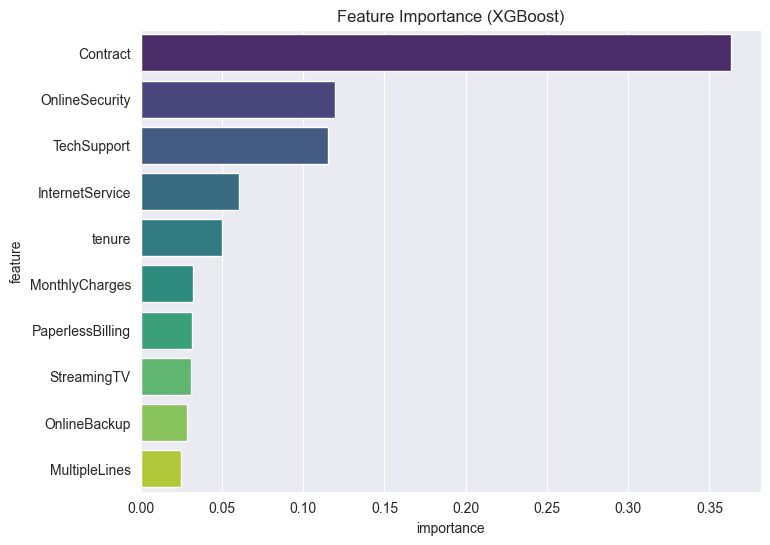

In [31]:
feature_importance = best_xgb.feature_importances_
features_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': feature_importance
}).sort_values(by='importance', ascending=False)

plt.figure(figsize=(8, 6))
sns.barplot(data=features_df.head(10), x='importance', y='feature', hue='feature', legend=False, palette='viridis')
plt.title('Feature Importance (XGBoost)')
plt.show()

## Выводы по интерпретации модели
- Самый сильный предиктор оттока: `Contract` (месячный контракт → высокий риск).
- Добавление OnlineSecurity и TechSupport снижает вероятность ухода.
- Рекомендация: предлагать клиентам с месячным контрактом bundled-услуги + продление до 1 года.